In [1]:
# =========================================================
# 0. 기본 라이브러리
# =========================================================
import json
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

from PIL import Image
from torchvision import transforms, models

# =========================================================
# 1. 기본 설정
# =========================================================
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

IMG_SIZE = 224

# =========================================================
# 2. 전처리
# =========================================================
val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# =========================================================
# 3. 클래스 이름 불러오기
# =========================================================
with open("class_names_38cls.json", "r", encoding="utf-8") as f:
    class_38 = json.load(f)

num_classes = len(class_38)

print("38클래스 개수:", num_classes)

# =========================================================
# 4. 모델 생성 함수
# =========================================================
def create_model(num_classes):

    model = models.efficientnet_b0(
        weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1
    )

    in_features = model.classifier[1].in_features

    model.classifier[1] = nn.Linear(
        in_features,
        num_classes
    )

    return model.to(DEVICE)

# =========================================================
# 5. 모델 로드
# =========================================================
model_38_extra406 = create_model(num_classes)

model_38_extra406.load_state_dict(
    torch.load(
        "model_reaf_ai_effb0_38cls_extra406_finetuned.pth",
        map_location=DEVICE
    )
)

model_38_extra406.eval()

print("모델 로드 완료")

38클래스 개수: 38
모델 로드 완료


/tmp/ipykernel_2108/3779208221.py:65: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  torch.load(


In [2]:
# =========================================================
# 작물 선택 기반 필터링 예측
# =========================================================
def predict_with_crop_filter(
    model,
    class_names,
    img_path,
    selected_crop,
    topk=5,
    threshold=0.7
):

    model.eval()

    # -------------------------
    # 이미지 전처리
    # -------------------------
    img = Image.open(img_path).convert("RGB")

    x = val_transform(img).unsqueeze(0).to(DEVICE)

    # -------------------------
    # 전체 클래스 예측
    # -------------------------
    with torch.no_grad():
        out = model(x)
        probs = torch.softmax(out, dim=1)[0]

    # -------------------------
    # 선택한 작물 클래스만 필터링
    # -------------------------
    filtered_indices = [
        i for i, name in enumerate(class_names)
        if name.startswith(selected_crop + "___")
    ]

    # 예외 처리
    if len(filtered_indices) == 0:
        print(f"{selected_crop} 관련 클래스 없음")
        return

    # -------------------------
    # 필터링된 확률 추출
    # -------------------------
    filtered_probs = probs[filtered_indices]

    # -------------------------
    # 선택 작물 안에서 Top-K
    # -------------------------
    top_values, top_positions = torch.topk(
        filtered_probs,
        k=min(topk, len(filtered_indices))
    )

    # -------------------------
    # 이미지 출력
    # -------------------------
    plt.figure(figsize=(6, 6))
    plt.imshow(img)
    plt.title(f"Selected Crop: {selected_crop}")
    plt.axis("off")
    plt.show()

    print("\n" + "=" * 70)
    print("이미지:", img_path)
    print("선택 작물:", selected_crop)
    print("=" * 70)

    print("===== 필터링 결과 =====")

    for rank, (value, pos) in enumerate(zip(top_values, top_positions), start=1):

        original_idx = filtered_indices[pos.item()]

        print(
            f"{rank}위: "
            f"{class_names[original_idx]} / "
            f"신뢰도: {value.item():.4f}"
        )

    # -------------------------
    # 최종 판단
    # -------------------------
    best_conf = top_values[0].item()
    best_idx = filtered_indices[top_positions[0].item()]

    print("\n===== 최종 판단 =====")

    if best_conf < threshold:
        print(f"판단 어려움 (신뢰도: {best_conf:.2f})")

    else:
        print(
            f"{class_names[best_idx]} "
            f"(신뢰도: {best_conf:.2f})"
        )

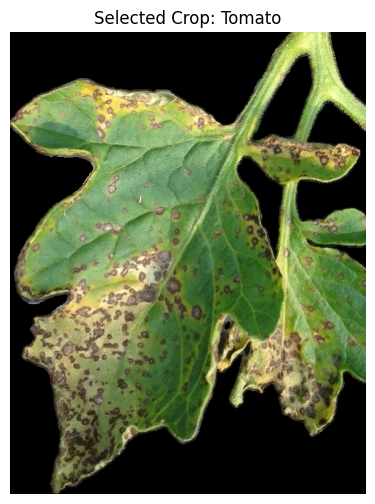


이미지: /home/harry/Re_leaf_Project/Test_image/셉토리아2_누끼.png
선택 작물: Tomato
===== 필터링 결과 =====
1위: Tomato___healthy / 신뢰도: 0.1050
2위: Tomato___Septoria_leaf_spot / 신뢰도: 0.0588
3위: Tomato___Early_blight / 신뢰도: 0.0272
4위: Tomato___Late_blight / 신뢰도: 0.0158
5위: Tomato___Target_Spot / 신뢰도: 0.0034

===== 최종 판단 =====
판단 어려움 (신뢰도: 0.10)


In [7]:
predict_with_crop_filter(
    model=model_38_extra406,
    class_names=class_38,
    img_path="/home/harry/Re_leaf_Project/Test_image/셉토리아2_누끼.png",
    selected_crop="Tomato",
    topk=5,
    threshold=0.7
)

In [8]:
# =========================================================
# 34개 클래스 실제 이미지 크롤링
# - 토마토 4개 클래스 제외
# - Google + Bing 사용
# - 클래스별 약 100장 이상 목표
# =========================================================

from icrawler.builtin import GoogleImageCrawler, BingImageCrawler
import os
import shutil

BASE_DIR = "real_crop_34cls"
TEMP_DIR = "crawl_temp_34cls"

os.makedirs(BASE_DIR, exist_ok=True)
os.makedirs(TEMP_DIR, exist_ok=True)

# =========================================================
# 크롤링 대상 클래스
# key   : 38cls 모델의 실제 라벨명
# value : 검색 키워드 목록
# =========================================================

classes = {
    "Apple___Apple_scab": [
        "apple scab leaf disease",
        "apple leaf scab disease close up",
        "apple scab infected leaf field"
    ],
    "Apple___Black_rot": [
        "apple black rot leaf",
        "apple black rot disease leaf close up",
        "apple black rot leaf disease field"
    ],
    "Apple___Cedar_apple_rust": [
        "cedar apple rust leaf",
        "apple cedar rust disease leaf",
        "cedar apple rust orange spots leaf"
    ],
    "Apple___healthy": [
        "healthy apple leaf",
        "apple healthy leaf close up",
        "apple tree healthy leaves"
    ],

    "Blueberry___healthy": [
        "healthy blueberry leaf",
        "blueberry healthy leaves",
        "blueberry plant leaf close up"
    ],

    "Cherry_(including_sour)___Powdery_mildew": [
        "cherry powdery mildew leaf",
        "cherry leaf powdery mildew disease",
        "sour cherry powdery mildew leaf"
    ],
    "Cherry_(including_sour)___healthy": [
        "healthy cherry leaf",
        "cherry tree healthy leaves",
        "sour cherry healthy leaf"
    ],

    "Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot": [
        "corn gray leaf spot",
        "maize cercospora leaf spot",
        "corn gray leaf spot disease close up"
    ],
    "Corn_(maize)___Common_rust_": [
        "corn common rust leaf",
        "maize common rust disease",
        "corn rust pustules leaf close up"
    ],
    "Corn_(maize)___Northern_Leaf_Blight": [
        "corn northern leaf blight",
        "maize northern leaf blight disease",
        "corn leaf blight long lesions"
    ],
    "Corn_(maize)___healthy": [
        "healthy corn leaf",
        "healthy maize leaf",
        "corn plant healthy leaves"
    ],

    "Grape___Black_rot": [
        "grape black rot leaf",
        "grape leaf black rot disease",
        "black rot grape leaf close up"
    ],
    "Grape___Esca_(Black_Measles)": [
        "grape esca disease leaf",
        "grape black measles leaf",
        "esca grape leaf symptoms"
    ],
    "Grape___Leaf_blight_(Isariopsis_Leaf_Spot)": [
        "grape leaf blight",
        "grape isariopsis leaf spot",
        "grape leaf spot disease"
    ],
    "Grape___healthy": [
        "healthy grape leaf",
        "grape vine healthy leaves",
        "grape leaf close up healthy"
    ],

    "Orange___Haunglongbing_(Citrus_greening)": [
        "citrus greening leaf",
        "orange huanglongbing leaf",
        "HLB citrus leaf symptoms"
    ],

    "Peach___Bacterial_spot": [
        "peach bacterial spot leaf",
        "peach leaf bacterial spot disease",
        "peach bacterial spot close up"
    ],
    "Peach___healthy": [
        "healthy peach leaf",
        "peach tree healthy leaves",
        "peach leaf close up healthy"
    ],

    "Pepper,_bell___Bacterial_spot": [
        "bell pepper bacterial spot leaf",
        "pepper bacterial spot leaf disease",
        "bell pepper leaf spot disease"
    ],
    "Pepper,_bell___healthy": [
        "healthy bell pepper leaf",
        "pepper plant healthy leaf",
        "bell pepper healthy leaves"
    ],

    "Potato___Early_blight": [
        "potato early blight leaf",
        "potato leaf early blight disease",
        "alternaria potato leaf"
    ],
    "Potato___Late_blight": [
        "potato late blight leaf",
        "potato leaf late blight disease",
        "phytophthora potato leaf"
    ],
    "Potato___healthy": [
        "healthy potato leaf",
        "potato plant healthy leaves",
        "potato leaf close up healthy"
    ],

    "Raspberry___healthy": [
        "healthy raspberry leaf",
        "raspberry plant healthy leaves",
        "raspberry leaf close up"
    ],

    "Soybean___healthy": [
        "healthy soybean leaf",
        "soybean plant healthy leaves",
        "soybean leaf close up healthy"
    ],

    "Squash___Powdery_mildew": [
        "squash powdery mildew leaf",
        "squash leaf powdery mildew disease",
        "zucchini powdery mildew leaf"
    ],

    "Strawberry___Leaf_scorch": [
        "strawberry leaf scorch",
        "strawberry leaf scorch disease",
        "strawberry leaf scorch close up"
    ],
    "Strawberry___healthy": [
        "healthy strawberry leaf",
        "strawberry plant healthy leaves",
        "strawberry leaf close up healthy"
    ],

    # 토마토 4개 제외:
    # Tomato___Bacterial_spot
    # Tomato___Early_blight
    # Tomato___Late_blight
    # Tomato___Septoria_leaf_spot

    "Tomato___Leaf_Mold": [
        "tomato leaf mold",
        "tomato leaf mold disease",
        "tomato leaf mold close up"
    ],
    "Tomato___Spider_mites Two-spotted_spider_mite": [
        "tomato spider mites leaf",
        "tomato two spotted spider mite damage",
        "tomato leaf spider mite damage"
    ],
    "Tomato___Target_Spot": [
        "tomato target spot leaf",
        "tomato target spot disease",
        "tomato leaf target spot close up"
    ],
    "Tomato___Tomato_Yellow_Leaf_Curl_Virus": [
        "tomato yellow leaf curl virus",
        "tomato yellow leaf curl disease",
        "TYLCV tomato leaf symptoms"
    ],
    "Tomato___Tomato_mosaic_virus": [
        "tomato mosaic virus leaf",
        "tomato mosaic virus symptoms",
        "tomato leaf mosaic virus disease"
    ],
    "Tomato___healthy": [
        "healthy tomato leaf",
        "tomato plant healthy leaves",
        "tomato leaf close up healthy"
    ],
}

# =========================================================
# 크롤링 설정
# =========================================================

MAX_PER_KEYWORD = 20   # 키워드 3개 × 검색엔진 2개 × 20장 = 최대 120장/클래스

# =========================================================
# 크롤링 실행
# =========================================================

for class_name, keywords in classes.items():
    print("\n" + "=" * 80)
    print(f"{class_name} 수집 시작")
    print("=" * 80)

    class_save_dir = os.path.join(BASE_DIR, class_name)
    os.makedirs(class_save_dir, exist_ok=True)

    img_count = 0

    for keyword_idx, keyword in enumerate(keywords, start=1):
        print(f"\n키워드 {keyword_idx}: {keyword}")

        for engine_name, Crawler in [
            ("google", GoogleImageCrawler),
            ("bing", BingImageCrawler)
        ]:
            temp_save_dir = os.path.join(
                TEMP_DIR,
                class_name,
                f"{engine_name}_{keyword_idx}"
            )

            os.makedirs(temp_save_dir, exist_ok=True)

            print(f"  {engine_name} 수집 중...")

            try:
                crawler = Crawler(storage={"root_dir": temp_save_dir})
                crawler.crawl(
                    keyword=keyword,
                    max_num=MAX_PER_KEYWORD
                )

                for fname in os.listdir(temp_save_dir):
                    if fname.lower().endswith((".jpg", ".jpeg", ".png", ".webp")):
                        src = os.path.join(temp_save_dir, fname)

                        ext = os.path.splitext(fname)[1].lower()
                        new_name = f"{class_name}_{engine_name}_{keyword_idx}_{img_count:04d}{ext}"
                        dst = os.path.join(class_save_dir, new_name)

                        shutil.copy(src, dst)
                        img_count += 1

            except Exception as e:
                print(f"  {engine_name} 오류:", e)

    print(f"\n{class_name} 수집 완료: {img_count}장")

print("\n전체 크롤링 완료")

2026-05-06 15:29:36,313 - INFO - icrawler.crawler - start crawling...
2026-05-06 15:29:36,314 - INFO - icrawler.crawler - starting 1 feeder threads...
2026-05-06 15:29:36,314 - INFO - feeder - thread feeder-001 exit
2026-05-06 15:29:36,315 - INFO - icrawler.crawler - starting 1 parser threads...
2026-05-06 15:29:36,316 - INFO - icrawler.crawler - starting 1 downloader threads...
2026-05-06 15:29:36,476 - INFO - parser - parsing result page https://www.google.com/search?q=apple+scab+leaf+disease&ijn=0&start=0&tbs=&tbm=isch
Exception in thread parser-001:
Traceback (most recent call last):
  File "/home/harry/miniconda3/envs/pytorch_gpu/lib/python3.11/threading.py", line 1045, in _bootstrap_inner
    self.run()
  File "/home/harry/miniconda3/envs/pytorch_gpu/lib/python3.11/threading.py", line 982, in run
    self._target(*self._args, **self._kwargs)
  File "/home/harry/miniconda3/envs/pytorch_gpu/lib/python3.11/site-packages/icrawler/parser.py", line 93, in worker_exec
    for task in se


Apple___Apple_scab 수집 시작

키워드 1: apple scab leaf disease
  google 수집 중...


2026-05-06 15:29:44,930 - INFO - downloader - no more download task for thread downloader-001
2026-05-06 15:29:44,932 - INFO - downloader - thread downloader-001 exit
2026-05-06 15:29:45,931 - INFO - icrawler.crawler - Crawling task done!
2026-05-06 15:29:45,935 - INFO - icrawler.crawler - start crawling...
2026-05-06 15:29:45,936 - INFO - icrawler.crawler - starting 1 feeder threads...
2026-05-06 15:29:45,937 - INFO - feeder - thread feeder-001 exit
2026-05-06 15:29:45,937 - INFO - icrawler.crawler - starting 1 parser threads...
2026-05-06 15:29:45,940 - INFO - icrawler.crawler - starting 1 downloader threads...


  bing 수집 중...


2026-05-06 15:29:46,276 - INFO - parser - parsing result page https://www.bing.com/images/async?q=apple scab leaf disease&first=0
2026-05-06 15:29:46,695 - INFO - downloader - image #1	https://www.thespruce.com/thmb/lIPQA2N6lO5TMvAg2m1mU6zmTAk=/3750x2500/filters:no_upscale():max_bytes(150000):strip_icc()/GettyImages-471452853-16f95d4cf38541ac8e55c60638600302.jpg
2026-05-06 15:29:47,673 - INFO - downloader - image #2	https://usercontent2.hubstatic.com/6577337.jpg
2026-05-06 15:29:52,988 - ERROR - downloader - Exception caught when downloading file https://homertree.com/wp-content/uploads/apple-scab-leaves-807x1024.jpg, error: HTTPSConnectionPool(host='homertree.com', port=443): Read timed out. (read timeout=5), remaining retry times: 2
2026-05-06 15:29:58,183 - ERROR - downloader - Exception caught when downloading file https://homertree.com/wp-content/uploads/apple-scab-leaves-807x1024.jpg, error: HTTPSConnectionPool(host='homertree.com', port=443): Read timed out. (read timeout=5), re

...

2026-05-06 16:29:35,828 - INFO - parser - parsing result page https://www.google.com/search?q=tomato+leaf+close+up+healthy&ijn=0&start=0&tbs=&tbm=isch
Exception in thread parser-001:
Traceback (most recent call last):
  File "/home/harry/miniconda3/envs/pytorch_gpu/lib/python3.11/threading.py", line 1045, in _bootstrap_inner
    self.run()
  File "/home/harry/miniconda3/envs/pytorch_gpu/lib/python3.11/threading.py", line 982, in run
    self._target(*self._args, **self._kwargs)
  File "/home/harry/miniconda3/envs/pytorch_gpu/lib/python3.11/site-packages/icrawler/parser.py", line 93, in worker_exec
    for task in self.parse(response, **kwargs):
TypeError: 'NoneType' object is not iterable
2026-05-06 16:29:40,509 - INFO - downloader - no more download task for thread downloader-001
2026-05-06 16:29:40,512 - INFO - downloader - thread downloader-001 exit
2026-05-06 16:29:41,512 - INFO - icrawler.crawler - Crawling task done!
2026-05-06 16:29:41,513 - INFO - icrawler.crawler - start crawl

  bing 수집 중...


2026-05-06 16:29:41,877 - INFO - parser - parsing result page https://www.bing.com/images/async?q=tomato leaf close up healthy&first=0
2026-05-06 16:29:41,931 - INFO - downloader - image #1	https://thumbs.dreamstime.com/b/close-up-healthy-tomato-plant-leaves-garden-close-up-healthy-tomato-plant-leaves-garden-380291705.jpg
2026-05-06 16:29:41,942 - INFO - downloader - image #2	https://thumbs.dreamstime.com/b/close-up-tomato-leaf-view-beautiful-young-green-tomatoes-plants-pots-concept-organic-food-farmer-s-vegetabes-health-245109695.jpg
2026-05-06 16:29:43,350 - INFO - downloader - image #3	https://c8.alamy.com/comp/WA7YEE/tomato-leaves-close-up-WA7YEE.jpg
2026-05-06 16:29:43,576 - INFO - downloader - image #4	https://www.shutterstock.com/image-photo/closeup-tomato-leaves-green-healthy-260nw-2206749191.jpg
2026-05-06 16:29:44,905 - INFO - downloader - image #5	https://c8.alamy.com/comp/M2Y2TH/tomato-plant-leaves-close-up-M2Y2TH.jpg
2026-05-06 16:29:47,151 - INFO - downloader - image #6	h


Tomato___healthy 수집 완료: 60장

전체 크롤링 완료


2026-05-06 16:29:57,120 - INFO - parser - downloaded image reached max num, thread parser-001 is ready to exit
2026-05-06 16:29:57,121 - INFO - parser - thread parser-001 exit


In [9]:
# =========================================================
# 클래스별 수집 개수 확인
# =========================================================

import os

for class_name in sorted(os.listdir("real_crop_34cls")):
    class_dir = os.path.join("real_crop_34cls", class_name)

    if os.path.isdir(class_dir):
        image_count = len([
            f for f in os.listdir(class_dir)
            if f.lower().endswith((".jpg", ".jpeg", ".png", ".webp"))
        ])

        print(class_name, ":", image_count, "장")

Apple___Apple_scab : 51 장
Apple___Black_rot : 60 장
Apple___Cedar_apple_rust : 53 장
Apple___healthy : 55 장
Blueberry___healthy : 60 장
Cherry_(including_sour)___Powdery_mildew : 48 장
Cherry_(including_sour)___healthy : 60 장
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot : 47 장
Corn_(maize)___Common_rust_ : 48 장
Corn_(maize)___Northern_Leaf_Blight : 50 장
Corn_(maize)___healthy : 55 장
Grape___Black_rot : 56 장
Grape___Esca_(Black_Measles) : 56 장
Grape___Leaf_blight_(Isariopsis_Leaf_Spot) : 58 장
Grape___healthy : 60 장
Orange___Haunglongbing_(Citrus_greening) : 58 장
Peach___Bacterial_spot : 60 장
Peach___healthy : 55 장
Pepper,_bell___Bacterial_spot : 56 장
Pepper,_bell___healthy : 60 장
Potato___Early_blight : 60 장
Potato___Late_blight : 60 장
Potato___healthy : 55 장
Raspberry___healthy : 60 장
Soybean___healthy : 60 장
Squash___Powdery_mildew : 60 장
Strawberry___Leaf_scorch : 60 장
Strawberry___healthy : 56 장
Tomato___Leaf_Mold : 55 장
Tomato___Spider_mites Two-spotted_spider_mite : 60 장
Tomato_

In [12]:
!pip install opencv-python

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.9/72.9 MB 41.1 MB/s  0:00:01 eta 0:00:01


In [3]:
# =========================================================
# 이미지 품질 보정 + 배경 최소화 전처리
# =========================================================

import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

def enhance_and_crop_leaf(img_path, show=True):
    # 1. 이미지 읽기
    img_bgr = cv2.imread(img_path)
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

    # 2. 대비 보정: LAB + CLAHE
    lab = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2LAB)
    l, a, b = cv2.split(lab)

    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    l_clahe = clahe.apply(l)

    lab_clahe = cv2.merge((l_clahe, a, b))
    enhanced = cv2.cvtColor(lab_clahe, cv2.COLOR_LAB2RGB)

    # 3. 노이즈 완화
    denoised = cv2.fastNlMeansDenoisingColored(
        enhanced,
        None,
        h=5,
        hColor=5,
        templateWindowSize=7,
        searchWindowSize=21
    )

    # 4. 샤프닝
    kernel = np.array([
        [0, -1, 0],
        [-1, 5, -1],
        [0, -1, 0]
    ])

    sharpened = cv2.filter2D(denoised, -1, kernel)

    # 5. 초록색 잎 영역 마스크 생성
    hsv = cv2.cvtColor(sharpened, cv2.COLOR_RGB2HSV)

    lower_green = np.array([25, 30, 30])
    upper_green = np.array([95, 255, 255])

    mask = cv2.inRange(hsv, lower_green, upper_green)

    # 6. 마스크 정리
    mask = cv2.medianBlur(mask, 7)

    contours, _ = cv2.findContours(
        mask,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE
    )

    # 7. 가장 큰 잎 영역 기준 crop
    if len(contours) > 0:
        largest = max(contours, key=cv2.contourArea)
        x, y, w, h = cv2.boundingRect(largest)

        # 여백 추가
        pad = 30
        x1 = max(x - pad, 0)
        y1 = max(y - pad, 0)
        x2 = min(x + w + pad, sharpened.shape[1])
        y2 = min(y + h + pad, sharpened.shape[0])

        cropped = sharpened[y1:y2, x1:x2]

    else:
        # 잎 영역 못 찾으면 원본 보정 이미지를 그대로 사용
        cropped = sharpened

    if show:
        plt.figure(figsize=(14, 5))

        plt.subplot(1, 3, 1)
        plt.imshow(img_rgb)
        plt.title("Original")
        plt.axis("off")

        plt.subplot(1, 3, 2)
        plt.imshow(sharpened)
        plt.title("Enhanced")
        plt.axis("off")

        plt.subplot(1, 3, 3)
        plt.imshow(cropped)
        plt.title("Leaf Crop")
        plt.axis("off")

        plt.show()

    return Image.fromarray(cropped)

In [14]:
# =========================================================
# 보정 이미지로 작물 필터링 예측
# =========================================================

def predict_with_preprocess_and_crop_filter(
    model,
    class_names,
    img_path,
    selected_crop="Tomato",
    topk=5,
    threshold=0.7
):
    model.eval()

    # 1. 이미지 보정 + 배경 최소화
    img = enhance_and_crop_leaf(img_path, show=True)

    # 2. 모델 입력 전처리
    x = val_transform(img).unsqueeze(0).to(DEVICE)

    # 3. 예측
    with torch.no_grad():
        out = model(x)
        probs = torch.softmax(out, dim=1)[0]

    # 4. 선택 작물 클래스만 필터링
    filtered_indices = [
        i for i, name in enumerate(class_names)
        if name.startswith(selected_crop + "___")
    ]

    filtered_probs = probs[filtered_indices]

    top_values, top_positions = torch.topk(
        filtered_probs,
        k=min(topk, len(filtered_indices))
    )

    print("\n" + "=" * 70)
    print("이미지:", img_path)
    print("선택 작물:", selected_crop)
    print("=" * 70)

    print("===== 전처리 + 작물 필터링 Top 결과 =====")

    for rank, (value, pos) in enumerate(zip(top_values, top_positions), start=1):
        original_idx = filtered_indices[pos.item()]
        print(f"{rank}위: {class_names[original_idx]} / 신뢰도: {value.item():.4f}")

    best_conf = top_values[0].item()
    best_idx = filtered_indices[top_positions[0].item()]

    print("\n===== 최종 판단 =====")
    if best_conf < threshold:
        print(f"판단 어려움 (신뢰도: {best_conf:.2f})")
    else:
        print(f"{class_names[best_idx]} (신뢰도: {best_conf:.2f})")

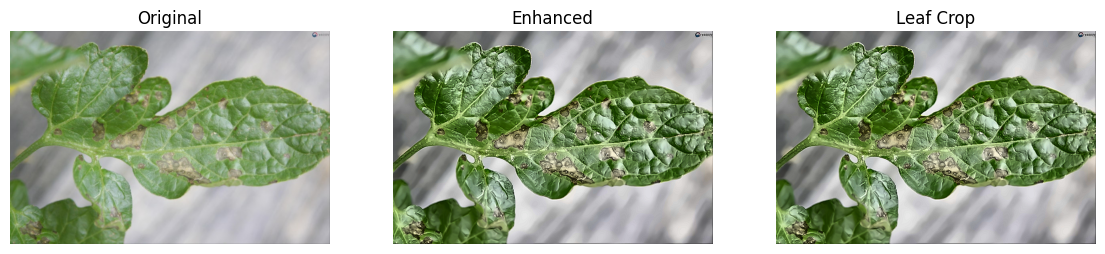


이미지: /home/harry/Re_leaf_Project/Test_image/점무늬병1.jpg
선택 작물: Tomato
===== 전처리 + 작물 필터링 Top 결과 =====
1위: Tomato___Early_blight / 신뢰도: 0.0194
2위: Tomato___Late_blight / 신뢰도: 0.0033
3위: Tomato___Target_Spot / 신뢰도: 0.0007
4위: Tomato___Septoria_leaf_spot / 신뢰도: 0.0000
5위: Tomato___Tomato_mosaic_virus / 신뢰도: 0.0000

===== 최종 판단 =====
판단 어려움 (신뢰도: 0.02)


In [15]:
predict_with_preprocess_and_crop_filter(
    model=model_38_extra406,
    class_names=class_38,
    img_path="/home/harry/Re_leaf_Project/Test_image/점무늬병1.jpg",
    selected_crop="Tomato",
    topk=5,
    threshold=0.7
)

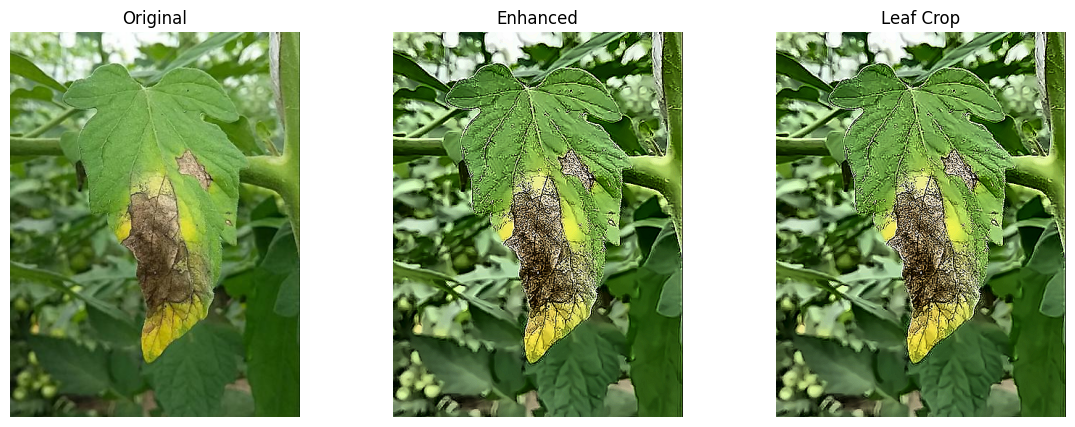


이미지: /home/harry/Re_leaf_Project/Test_image/후기역병1.jpg
선택 작물: Tomato
===== 전처리 + 작물 필터링 Top 결과 =====
1위: Tomato___Late_blight / 신뢰도: 0.5918
2위: Tomato___Spider_mites Two-spotted_spider_mite / 신뢰도: 0.0118
3위: Tomato___Early_blight / 신뢰도: 0.0097
4위: Tomato___Leaf_Mold / 신뢰도: 0.0064
5위: Tomato___Tomato_Yellow_Leaf_Curl_Virus / 신뢰도: 0.0018

===== 최종 판단 =====
판단 어려움 (신뢰도: 0.59)


In [16]:
predict_with_preprocess_and_crop_filter(
    model=model_38_extra406,
    class_names=class_38,
    img_path="/home/harry/Re_leaf_Project/Test_image/후기역병1.jpg",
    selected_crop="Tomato",
    topk=5,
    threshold=0.7
)

In [17]:
# =========================================================
# 원본 vs 전처리 비교 예측
# =========================================================

def compare_original_vs_preprocessed(
    model,
    class_names,
    img_path,
    selected_crop="Tomato",
    topk=5,
    threshold=0.7
):

    model.eval()

    # =====================================================
    # 1. 원본 이미지
    # =====================================================
    original_img = Image.open(img_path).convert("RGB")

    x_original = val_transform(original_img).unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        out_original = model(x_original)
        probs_original = torch.softmax(out_original, dim=1)[0]

    # =====================================================
    # 2. 전처리 이미지
    # =====================================================
    processed_img = enhance_and_crop_leaf(img_path, show=False)

    x_processed = val_transform(processed_img).unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        out_processed = model(x_processed)
        probs_processed = torch.softmax(out_processed, dim=1)[0]

    # =====================================================
    # 3. 작물 필터링
    # =====================================================
    filtered_indices = [
        i for i, name in enumerate(class_names)
        if name.startswith(selected_crop + "___")
    ]

    original_filtered = probs_original[filtered_indices]
    processed_filtered = probs_processed[filtered_indices]

    # =====================================================
    # 4. Top-K 계산
    # =====================================================
    orig_vals, orig_pos = torch.topk(
        original_filtered,
        k=min(topk, len(filtered_indices))
    )

    proc_vals, proc_pos = torch.topk(
        processed_filtered,
        k=min(topk, len(filtered_indices))
    )

    # =====================================================
    # 5. 이미지 비교 출력
    # =====================================================
    plt.figure(figsize=(12, 6))

    plt.subplot(1, 2, 1)
    plt.imshow(original_img)
    plt.title("Original")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(processed_img)
    plt.title("Preprocessed")
    plt.axis("off")

    plt.show()

    # =====================================================
    # 6. 결과 출력
    # =====================================================
    print("\n" + "=" * 80)
    print("이미지:", img_path)
    print("선택 작물:", selected_crop)
    print("=" * 80)

    # -------------------------
    # 원본 결과
    # -------------------------
    print("\n===== 원본 이미지 결과 =====")

    for rank, (value, pos) in enumerate(zip(orig_vals, orig_pos), start=1):

        idx = filtered_indices[pos.item()]

        print(
            f"{rank}위: "
            f"{class_names[idx]} / "
            f"신뢰도: {value.item():.4f}"
        )

    orig_best_conf = orig_vals[0].item()
    orig_best_idx = filtered_indices[orig_pos[0].item()]

    print("최종 판단:")

    if orig_best_conf < threshold:
        print(f"판단 어려움 ({orig_best_conf:.2f})")

    else:
        print(
            f"{class_names[orig_best_idx]} "
            f"({orig_best_conf:.2f})"
        )

    # -------------------------
    # 전처리 결과
    # -------------------------
    print("\n===== 전처리 이미지 결과 =====")

    for rank, (value, pos) in enumerate(zip(proc_vals, proc_pos), start=1):

        idx = filtered_indices[pos.item()]

        print(
            f"{rank}위: "
            f"{class_names[idx]} / "
            f"신뢰도: {value.item():.4f}"
        )

    proc_best_conf = proc_vals[0].item()
    proc_best_idx = filtered_indices[proc_pos[0].item()]

    print("최종 판단:")

    if proc_best_conf < threshold:
        print(f"판단 어려움 ({proc_best_conf:.2f})")

    else:
        print(
            f"{class_names[proc_best_idx]} "
            f"({proc_best_conf:.2f})"
        )

    # =====================================================
    # 7. 성능 비교
    # =====================================================
    print("\n===== 신뢰도 비교 =====")

    diff = proc_best_conf - orig_best_conf

    print(f"원본 최고 신뢰도     : {orig_best_conf:.4f}")
    print(f"전처리 최고 신뢰도   : {proc_best_conf:.4f}")

    if diff > 0:
        print(f"신뢰도 상승 ▲ (+{diff:.4f})")

    elif diff < 0:
        print(f"신뢰도 하락 ▼ ({diff:.4f})")

    else:
        print("변화 없음")

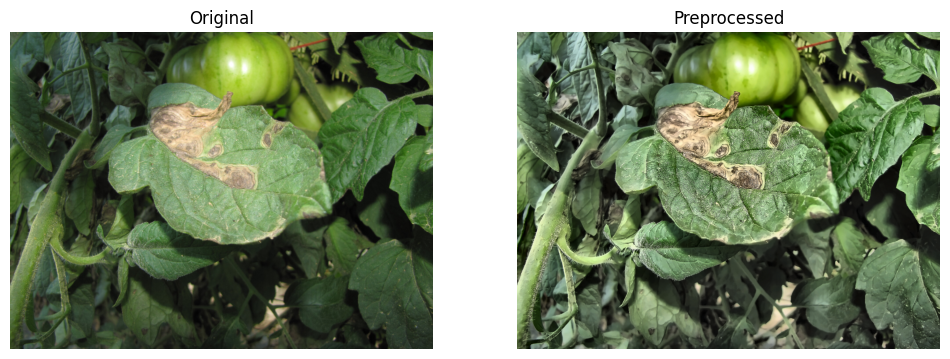


이미지: /home/harry/Re_leaf_Project/Test_image/전기역병1.jpg
선택 작물: Tomato

===== 원본 이미지 결과 =====
1위: Tomato___Early_blight / 신뢰도: 0.1978
2위: Tomato___Late_blight / 신뢰도: 0.1279
3위: Tomato___Target_Spot / 신뢰도: 0.0911
4위: Tomato___Bacterial_spot / 신뢰도: 0.0100
5위: Tomato___Tomato_Yellow_Leaf_Curl_Virus / 신뢰도: 0.0094
최종 판단:
판단 어려움 (0.20)

===== 전처리 이미지 결과 =====
1위: Tomato___Target_Spot / 신뢰도: 0.5151
2위: Tomato___Late_blight / 신뢰도: 0.1194
3위: Tomato___Early_blight / 신뢰도: 0.0976
4위: Tomato___healthy / 신뢰도: 0.0804
5위: Tomato___Tomato_Yellow_Leaf_Curl_Virus / 신뢰도: 0.0273
최종 판단:
판단 어려움 (0.52)

===== 신뢰도 비교 =====
원본 최고 신뢰도     : 0.1978
전처리 최고 신뢰도   : 0.5151
신뢰도 상승 ▲ (+0.3173)


In [19]:
compare_original_vs_preprocessed(
    model=model_38_extra406,
    class_names=class_38,
    img_path="/home/harry/Re_leaf_Project/Test_image/전기역병1.jpg",
    selected_crop="Tomato",
    topk=5,
    threshold=0.7
)

In [4]:
PREPROCESSED_DIR = "/home/harry/Re_leaf_Project/tomato_real_38cls_preprocessed"

# 클래스 불러오기
with open("class_names_38cls.json", "r", encoding="utf-8") as f:
    class_38 = json.load(f)

num_classes = len(class_38)

# 기존 토마토 원본 추가학습 모델 로드
model_pre_extra = create_model(num_classes)

model_pre_extra.load_state_dict(
    torch.load(
        "model_reaf_ai_effb0_38cls_extra406_finetuned.pth",
        map_location=DEVICE
    )
)

model_pre_extra.to(DEVICE)
model_pre_extra.train()

# 전처리 데이터셋 로드
preprocessed_ds = datasets.ImageFolder(
    PREPROCESSED_DIR,
    transform=train_transform
)

preprocessed_loader = DataLoader(
    preprocessed_ds,
    batch_size=BATCH_SIZE,
    shuffle=True
)

print("전처리 이미지 수:", len(preprocessed_ds))
print("전처리 클래스:", preprocessed_ds.classes)

/tmp/ipykernel_2108/1360133517.py:13: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  torch.load(


NameError: name 'datasets' is not defined